In [1]:
import os
import sys
sys.path.insert(0,os.path.abspath('../src/'))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt

from topo_edit_util import map_mask, mom6_latlon2ij


In [3]:
path_old = '/glade/scratch/gmarques/archive/b.cesm3_cam058_mom_e.B1850WscMOM.ne30_L58_t061.camdev_cice5.026g/ocn/hist/'
file_old = 'b.cesm3_cam058_mom_e.B1850WscMOM.ne30_L58_t061.camdev_cice5.026g.mom6.static.nc'
df_old = xr.open_dataset(path_old+file_old)

df_old = df_old.rename({'xh':'lonh','yh':'lath','xq':'lonq','yq':'latq'})
df_old

<xarray.Dataset>
Dimensions:      (lonh: 540, lath: 458, time: 1, lonq: 540, latq: 458)
Coordinates:
  * lonh         (lonh) float64 -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
  * lath         (lath) float64 -79.2 -79.08 -78.95 -78.82 ... 87.64 87.71 87.74
  * time         (time) object 0001-01-01 00:00:00
  * lonq         (lonq) float64 -286.3 -285.7 -285.0 -284.3 ... 71.67 72.33 73.0
  * latq         (latq) float64 -79.14 -79.01 -78.89 ... 87.68 87.73 87.74
Data variables: (12/15)
    geolon       (lath, lonh) float32 ...
    geolat       (lath, lonh) float32 ...
    geolon_c     (latq, lonq) float32 ...
    geolat_c     (latq, lonq) float32 ...
    geolon_u     (lath, lonq) float32 ...
    geolat_u     (lath, lonq) float32 ...
    ...           ...
    depth_ocean  (lath, lonh) float32 ...
    wet          (lath, lonh) float32 ...
    wet_c        (latq, lonq) float32 ...
    wet_u        (lath, lonq) float32 ...
    wet_v        (latq, lonh) float32 ...
    Coriolis     (latq, lonq) float32 ...
Attributes:
    filename:   b.cesm3_cam058_mom_e.B1850WscMOM.ne30_L58_t061.camdev_cice5.0...
    title:      MOM6 diagnostic fields table for CESM case: b.cesm3_cam058_mo...
    grid_type:  regular
    grid_tile:  N/A

In [4]:
path_new = '/glade/scratch/bryan/tx2_3v2/'
file_new = 'topo.sub150.tx2_3v2.srtm.edit4.SmL1.0_C1.0.nc'
df_new = xr.open_dataset(path_new+file_new)

In [5]:
df_new_sub = xr.Dataset()
df_new_sub['mask'] = df_new['mask'][-458:,:]
df_new_sub['depth'] = df_new['D_interp'][-458:,:]
df_new_sub['geolat'] = df_new['geolat'][-458:,:]
df_new_sub['geolon'] = df_new['geolon'][-458:,:]
df_new_sub['geolatb'] = df_new['geolatb'][-458:,:]
df_new_sub['geolonb'] = df_new['geolonb'][-458:,:]

df_new_sub['lonh'] = df_old['lonh']
df_new_sub['lath'] = df_old['lath']

df_new_sub

<xarray.Dataset>
Dimensions:  (lonh: 540, lath: 458, lonq: 541, latq: 458)
Coordinates:
  * lonh     (lonh) float64 -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
  * lath     (lath) float64 -79.2 -79.08 -78.95 -78.82 ... 87.64 87.71 87.74
  * lonq     (lonq) float64 -287.0 -286.3 -285.7 -285.0 ... 71.67 72.33 73.0
  * latq     (latq) float64 -79.05 -78.92 -78.79 -78.66 ... 89.46 89.72 89.91
Data variables:
    mask     (lath, lonh) int32 ...
    depth    (lath, lonh) float32 ...
    geolat   (lath, lonh) float64 ...
    geolon   (lath, lonh) float64 ...
    geolatb  (latq, lonq) float64 ...
    geolonb  (latq, lonq) float64 ...

In [6]:
nlath = df_new_sub.sizes['lath']
nlonh = df_new_sub.sizes['lonh']

In [7]:
print(np.abs(df_old['geolat']).min().values)
print(np.abs(df_new['geolat']).min().values)


0.062499966472387314
0.0


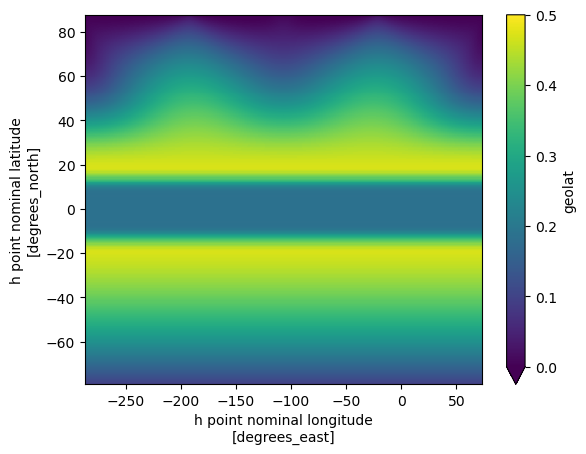

In [8]:
latdiff = df_new_sub['geolat'] - df_old['geolat']
latdiff.plot(vmin=0,vmax=0.5)

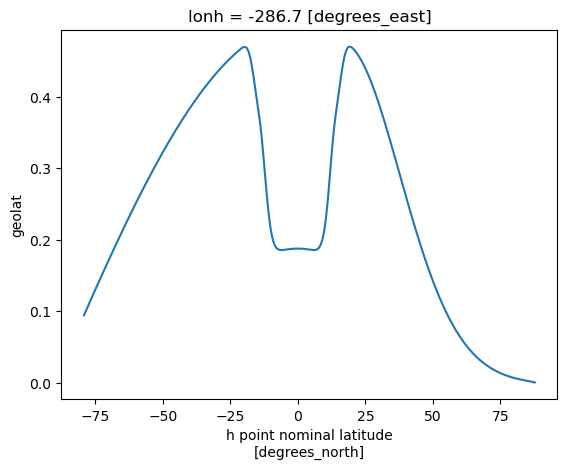

In [9]:

latdiff[:,0].plot()

In [10]:
maskdiff = df_new_sub['mask'] - df_old['wet']
df_new_sub['maskdiff']=maskdiff

zdiff = df_new_sub['depth'] - df_old['depth_ocean']
df_new_sub['zdiff']=zdiff

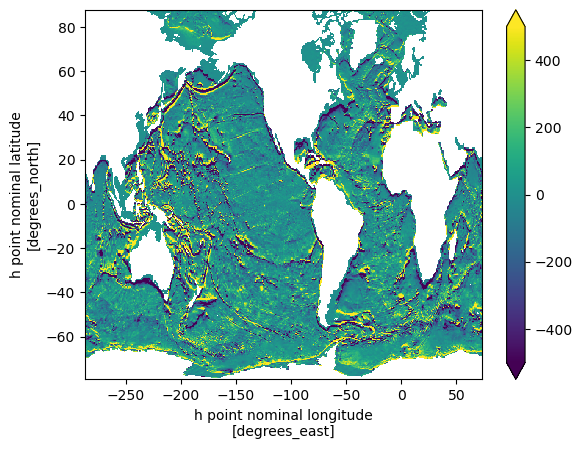

In [11]:
zdiff.plot(vmin=-500,vmax=500)

In [12]:
zdiff

<xarray.DataArray (lath: 458, lonh: 540)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lonh     (lonh) float64 -286.7 -286.0 -285.3 -284.7 ... 71.33 72.0 72.67
  * lath     (lath) float64 -79.2 -79.08 -78.95 -78.82 ... 87.64 87.71 87.74

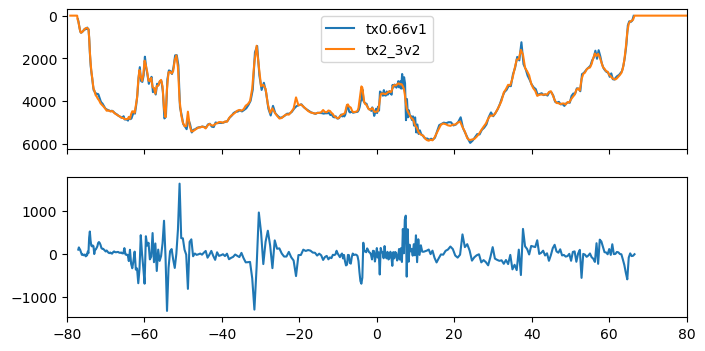

In [13]:
fig,ax=plt.subplots(nrows=2,sharex=True,figsize=(8,4))

ax[0].plot(df_old['geolat'].isel(lonh=-160),
           df_old['depth_ocean'].isel(lonh=-160),label='tx0.66v1')
ax[0].plot(df_new_sub['geolat'].isel(lonh=-160),
           df_new_sub['depth'].isel(lonh=-160),label='tx2_3v2')
ax[0].invert_yaxis()
ax[0].legend()
ax[0].set_xlim(-80,80)

ax[1].plot(df_new_sub['geolat'].isel(lonh=-160),
           df_new_sub['zdiff'].isel(lonh=-160))


/glade/u/apps/opt/conda/envs/npl-2023b/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


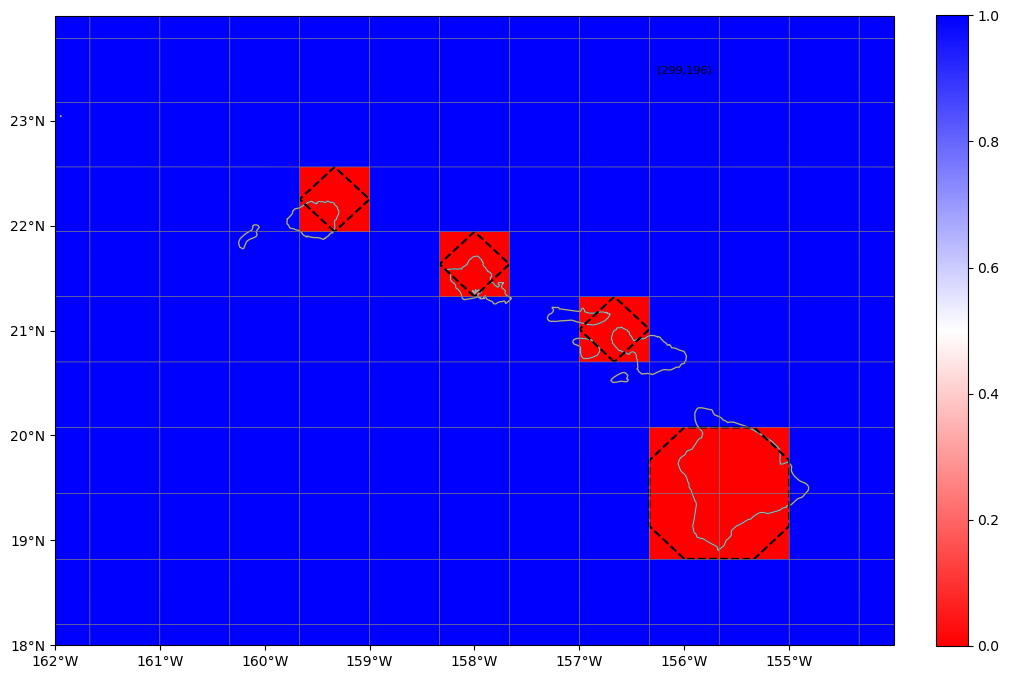

In [14]:
lonbeg=-162
lonend=-154
latbeg=18
latend=24

map_mask(df_old,'wet',lonbeg,lonend,latbeg,latend,
         vlon='geolon',vlat='geolat',vlone='geolon_c',vlate='geolat_c')

/glade/u/apps/opt/conda/envs/npl-2023b/lib/python3.10/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


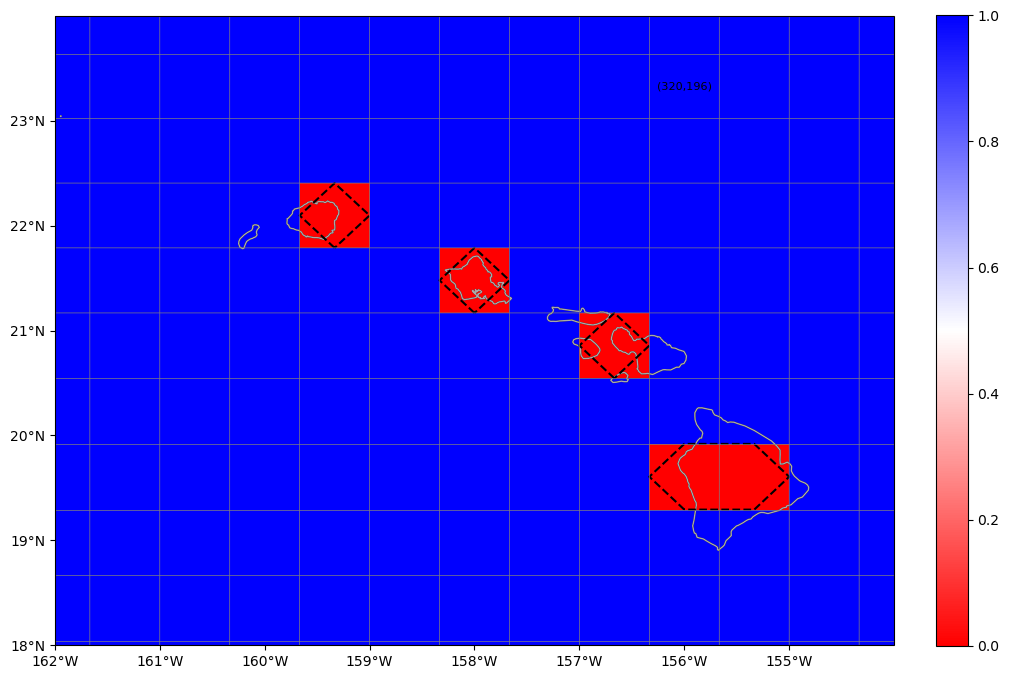

In [15]:
map_mask(df_new,'mask',lonbeg,lonend,latbeg,latend)

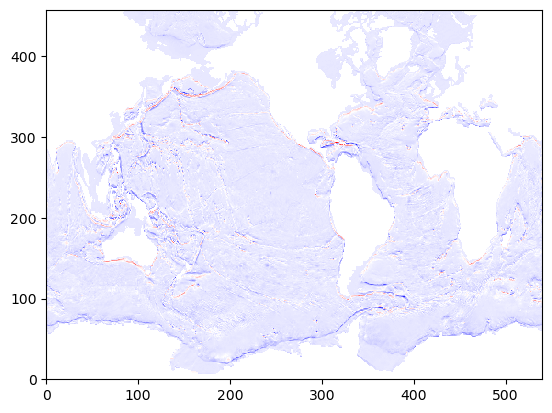

In [16]:
plt.pcolormesh(zdiff)

In [17]:
def compare_masks_ij(lonbeg,lonend,latbeg,latend):
    
    fig,ax=plt.subplots(nrows=2,ncols=2,sharex=True,sharey=True,
                        figsize=(10,7),constrained_layout=True)

    ax[0,0].pcolormesh(df_old['wet'].sel(lath=slice(latbeg,latend),
                                         lonh=slice(lonbeg,lonend)),
                      vmin=0,vmax=1)
    ax[0,0].grid(True)
    ax[0,0].set_title('tx0.66v1')

    ax[0,1].pcolormesh(df_new_sub['mask'].sel(lath=slice(latbeg,latend),
                                              lonh=slice(lonbeg,lonend)),
                      vmin=0,vmax=1)
    ax[0,1].grid(True)
    ax[0,1].set_title('tx2_3v2');
    
    diff = df_new_sub['mask'] - df_old['wet']

    ax[1,0].pcolormesh(diff.sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                      vmin=-1,vmax=1)
    ax[1,0].grid(True)
    ax[1,0].set_title('tx2_3v2 - tx0.66v1');


In [18]:
def compare_masks_geo(lonbeg,lonend,latbeg,latend):
    
    fig,ax=plt.subplots(nrows=2,ncols=2,sharex=True,sharey=True,
                        figsize=(10,7),constrained_layout=True)

    ax[0,0].pcolormesh(df_old['geolon'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                       df_old['geolat'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                       df_old['wet'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                      vmin=0,vmax=1)
    ax[0,0].grid(True)
    ax[0,0].set_title('tx0.66v1')

    ax[0,1].pcolormesh(df_new_sub['geolon'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                       df_new_sub['geolat'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                       df_new_sub['mask'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                      vmin=0,vmax=1)
    ax[0,1].grid(True)
    ax[0,1].set_title('tx2_3v1')
    
    diff = df_new_sub['mask'] - df_old['wet']

    ax[1,0].pcolormesh(df_old['geolon'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                       df_old['geolat'].sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                       diff.sel(lath=slice(latbeg,latend),lonh=slice(lonbeg,lonend)),
                      vmin=-1,vmax=1)
    ax[1,0].grid(True)
    ax[1,0].set_title('tx2_3v2 - tx0.66v1')


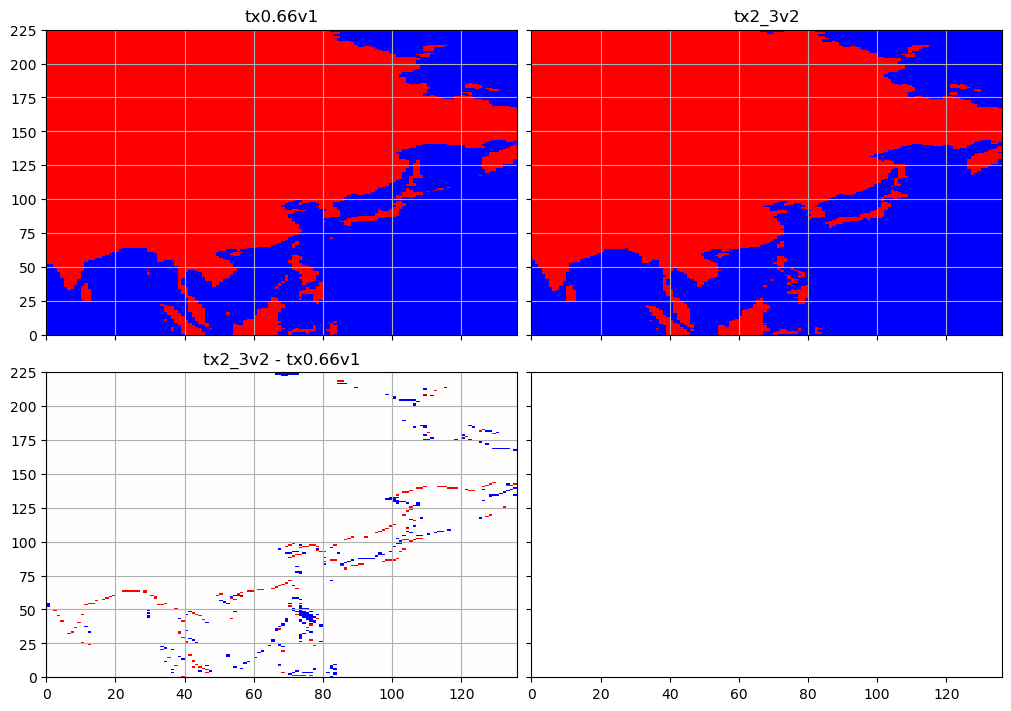

In [19]:
lonbeg=df_old['lonh'][0]
lonend=lonbeg+90
latend=90
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

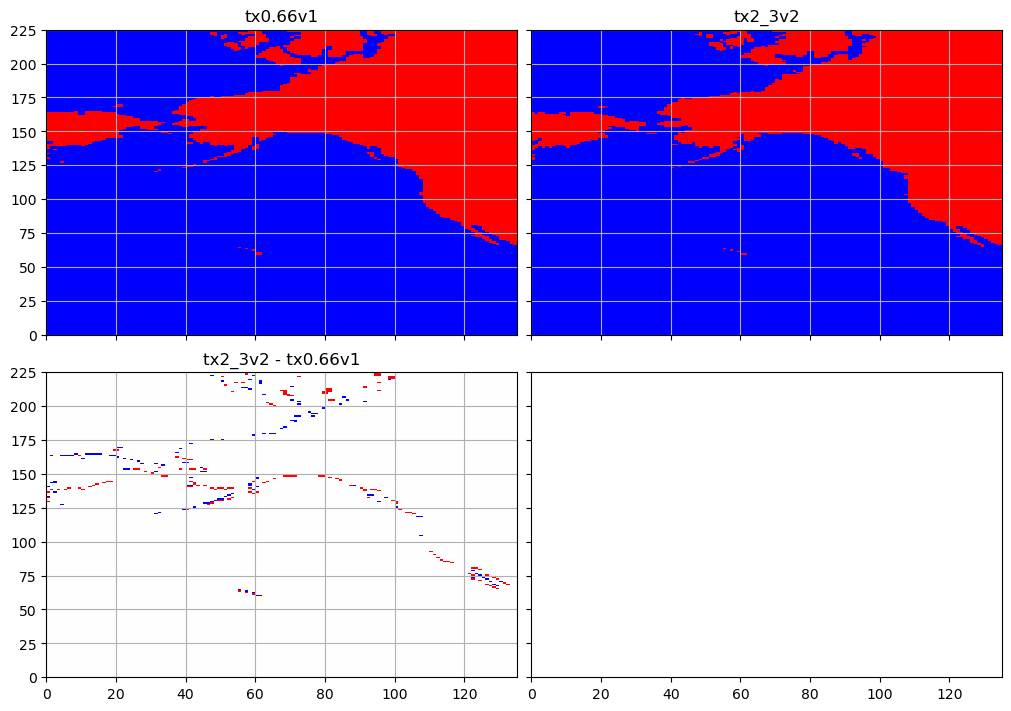

In [20]:
lonbeg=df_old['lonh'][0]+90
lonend=lonbeg+90
latend=90
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

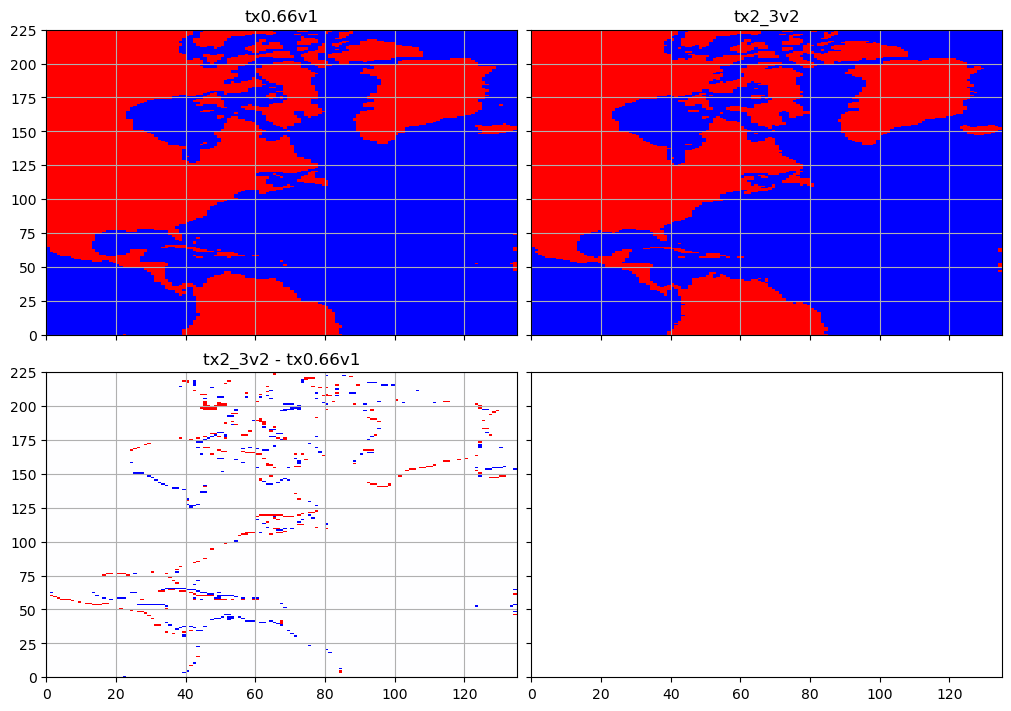

In [21]:
lonbeg=df_old['lonh'][0]+180
lonend=lonbeg+90
latend=90
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)


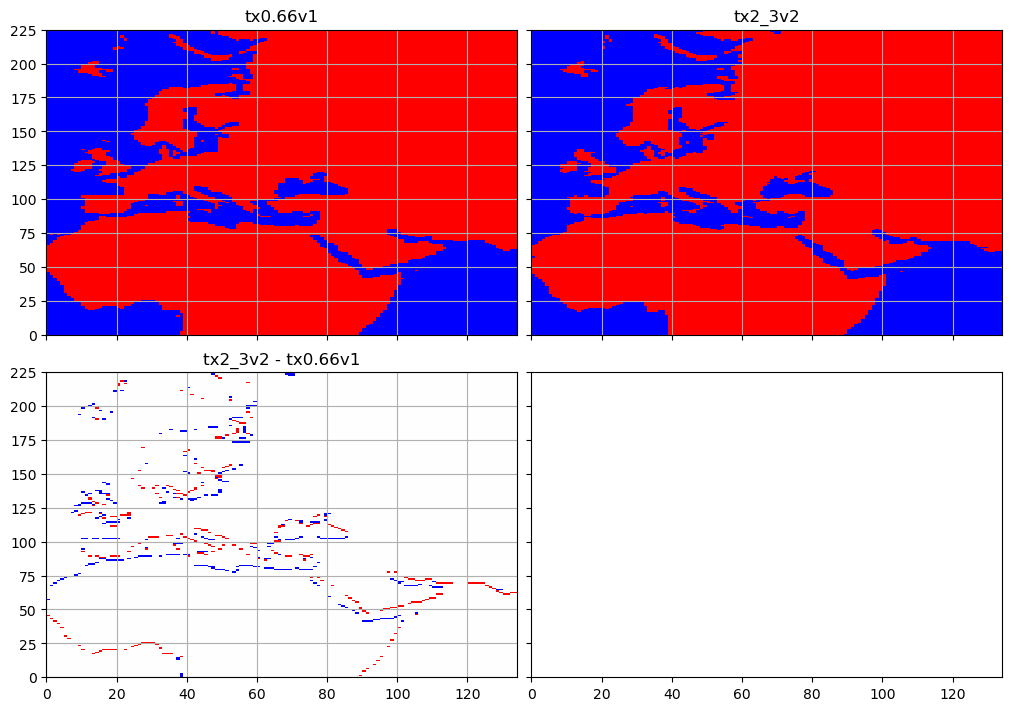

In [22]:
lonbeg=df_old['lonh'][0]+270
lonend=lonbeg+90
latend=90
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

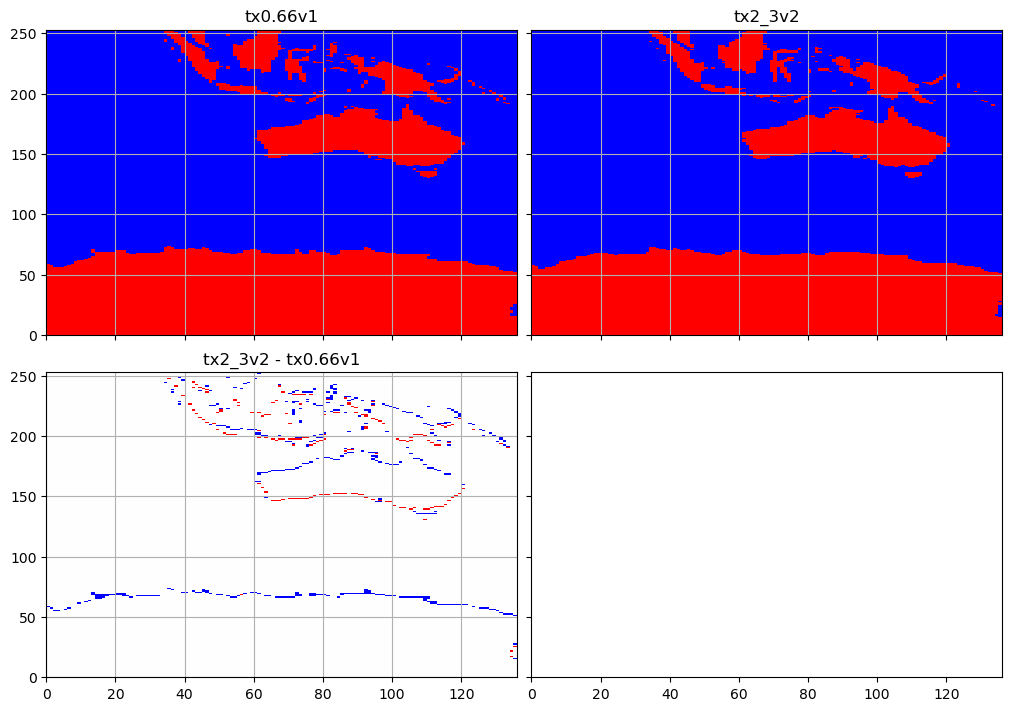

In [23]:
lonbeg=df_old['lonh'][0]
lonend=lonbeg+90
latend=5
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

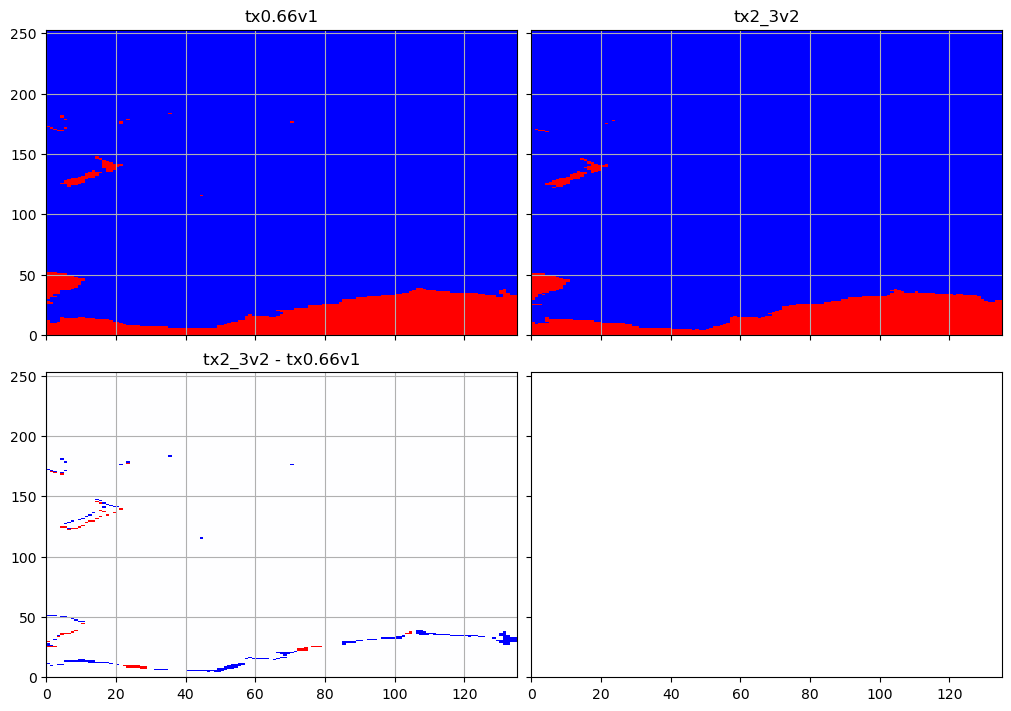

In [24]:
lonbeg=df_old['lonh'][0]+90
lonend=lonbeg+90
latend=5
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

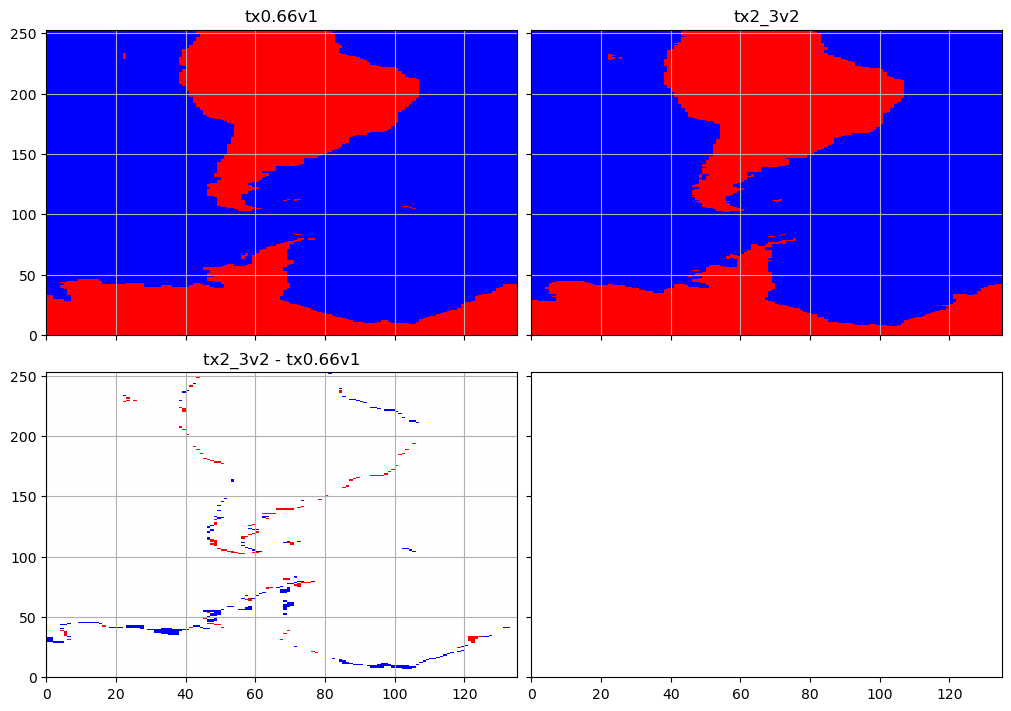

In [25]:
lonbeg=df_old['lonh'][0]+180
lonend=lonbeg+90
latend=5
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

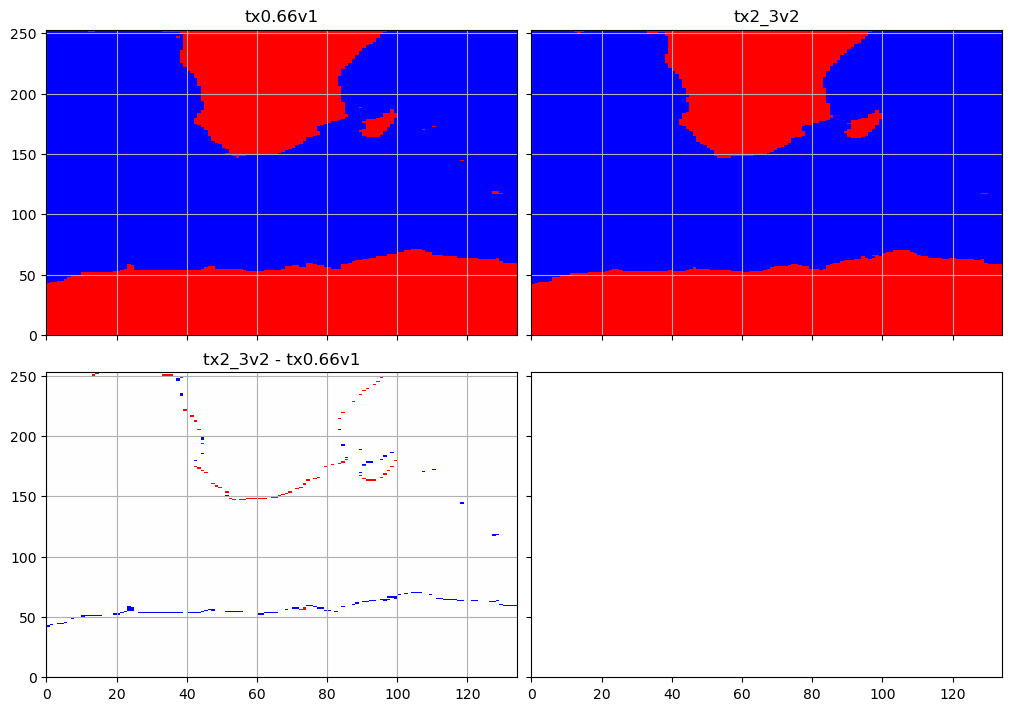

In [26]:
lonbeg=df_old['lonh'][0]+270
lonend=lonbeg+90
latend=5
latbeg=latend-90

compare_masks_ij(lonbeg,lonend,latbeg,latend)

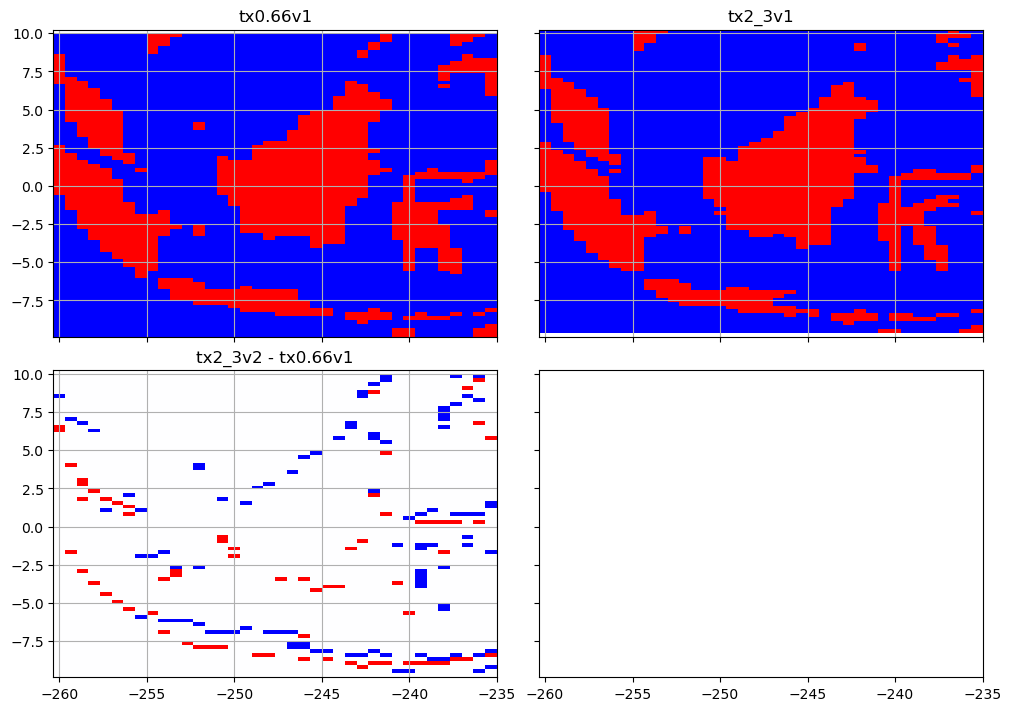

In [27]:
lonbeg=-260
lonend=-235
latend=10
latbeg=-10

compare_masks_geo(lonbeg,lonend,latbeg,latend)

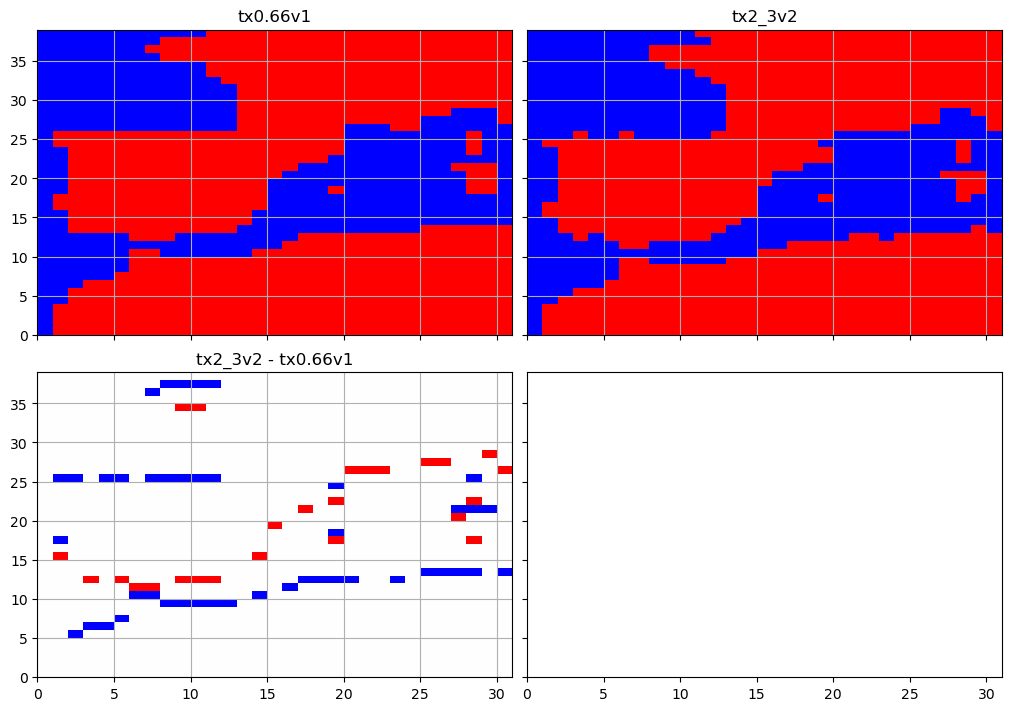

In [28]:
lonbeg=-10
lonend=10
latend=50
latbeg=30

compare_masks_ij(lonbeg,lonend,latbeg,latend)